# Ejercicio 2 — Agrupamiento y análisis comparativo de series

**¿Qué series de tiempo se parecen entre sí cuando se las representa mediante sus 22 características catch22, y qué revela esa similitud que no era visible en el análisis exploratorio tradicional?**

Este notebook responde los incisos **2.5–2.13**:

- **2.5** — cinco análisis comparativos: componentes principales, agrupamiento, mapa de calor de características, matriz de correlaciones y mapa de distancias;
- **2.6–2.13** — la interpretación de esos resultados: series similares, características discriminantes, grupos naturales, correspondencia con las categorías conocidas, series atípicas, contraste con el Laboratorio 1 y hallazgos nuevos.

Los insumos provienen de `03_extraccion_catch22.ipynb`. Aquí **no se recalcula catch22**.

## 0. Preparación

Se cargan los tres CSV generados por el notebook 03 (`series_mensuales.csv`, `catch22_features.csv` y `catch22_features_scaled.csv`) y se comprueba que conserven las dimensiones, el índice y el orden de series esperados.

Todos los análisis comparativos de este notebook se realizan sobre la **matriz estandarizada** de 7 × 22. Usar la matriz sin escalar haría que las características con rangos más amplios dominaran las distancias y las componentes principales.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# Localizar la raíz del repositorio para no depender del directorio de trabajo
# desde el que se abra el notebook.
ubicacion = Path.cwd().resolve()
ROOT = None

for carpeta in [ubicacion, *ubicacion.parents]:
    if (carpeta / "L02_DL_series" / "src" / "pipeline_catch22.py").exists():
        ROOT = carpeta
        break

if ROOT is None:
    raise FileNotFoundError(
        "No se encontró L02_DL_series/src/pipeline_catch22.py."
    )

SRC = ROOT / "L02_DL_series" / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from pipeline_catch22 import NOMBRES_SERIES, RUTA_SALIDA

# Semilla única: todo lo estocástico del notebook la reutiliza.
SEMILLA = 42

series = pd.read_csv(
    RUTA_SALIDA / "series_mensuales.csv",
    index_col="Fecha",
    parse_dates=True,
)

catch22 = pd.read_csv(
    RUTA_SALIDA / "catch22_features.csv",
    index_col="serie",
)

catch22_z = pd.read_csv(
    RUTA_SALIDA / "catch22_features_scaled.csv",
    index_col="serie",
)

# Color fijo por serie, compartido por todas las gráficas del notebook para
# que una misma serie se reconozca de un análisis a otro.
COLOR_SERIE = dict(
    zip(NOMBRES_SERIES, sns.color_palette("tab10", len(NOMBRES_SERIES)))
)

print("Raíz del proyecto :", ROOT)
print("Series mensuales  :", series.shape)
print("Catch22           :", catch22.shape)
print("Catch22 estandar. :", catch22_z.shape)

display(catch22_z.round(2))

Raíz del proyecto : /home/ricgo/2026_S2/Data/Data-Science
Series mensuales  : (210, 7)
Catch22           : (7, 22)
Catch22 estandar. : (7, 22)


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
serie,,,,,,,,,,,,,,,,,,,,,
total_internacional,-1.49,-0.74,1.80,-0.65,1.41,0.20,0.27,1.24,0.46,-1.06,...,-0.68,1.09,-0.36,1.93,-0.87,-0.82,0.69,-1.15,-0.74,-1.75
aerea,-0.91,0.39,-0.39,2.16,-0.96,-1.74,0.63,0.61,-0.74,1.31,...,-0.05,-0.75,-0.50,-0.64,-0.87,0.80,0.69,0.87,-0.05,0.39
terrestre,0.76,0.06,0.47,-0.65,1.08,0.24,0.37,0.26,-0.34,-1.06,...,-0.35,-0.65,-0.36,0.62,1.15,-1.20,0.62,0.87,-0.57,-0.68
maritima,-1.00,-1.87,-1.48,0.75,-1.57,-0.59,-2.43,-1.14,-0.95,1.31,...,2.40,-1.21,2.44,-0.89,-0.87,-0.64,0.69,0.87,2.37,1.54
america_centro,1.05,1.40,0.27,-0.30,0.46,-0.33,0.22,1.17,-0.34,0.13,...,-0.35,-0.80,-0.50,0.57,1.15,-0.73,0.46,0.87,-0.40,-0.52
america_norte,0.85,-0.14,0.33,-0.65,-0.49,0.42,0.47,-0.93,2.23,-1.06,...,-0.68,1.18,-0.50,-1.03,-0.87,1.28,-1.54,-1.15,-0.57,0.25
europa,0.74,0.90,-1.00,-0.65,0.08,1.80,0.47,-1.21,-0.32,0.42,...,-0.29,1.15,-0.22,-0.56,1.15,1.30,-1.61,-1.15,-0.05,0.78


In [2]:
# Si algo cambió en el notebook 03, es preferible fallar aquí que arrastrar
# el error silenciosamente hasta el PCA y el agrupamiento.

assert series.shape == (210, 7)
assert catch22.shape == (7, 22)
assert catch22_z.shape == (7, 22)

assert list(series.columns) == NOMBRES_SERIES
assert list(catch22.index) == NOMBRES_SERIES
assert list(catch22_z.index) == NOMBRES_SERIES
assert list(catch22_z.columns) == list(catch22.columns)

assert not series.index.has_duplicates
assert series.index.is_monotonic_increasing

assert np.isfinite(series.to_numpy(dtype=float)).all()
assert np.isfinite(catch22.to_numpy(dtype=float)).all()
assert np.isfinite(catch22_z.to_numpy(dtype=float)).all()

# La estandarización aplicada en el notebook 03 debe seguir vigente en el CSV.
assert np.allclose(catch22_z.mean(axis=0), 0.0, atol=1e-10)
assert np.allclose(catch22_z.std(axis=0, ddof=0), 1.0, atol=1e-10)

# Ninguna característica constante: todas aportan algo de separación.
assert (catch22.nunique() > 1).all()

print("Validación de los tres archivos: CORRECTA")
print("Período:", series.index.min().date(), "a", series.index.max().date())
print("Series :", ", ".join(NOMBRES_SERIES))

Validación de los tres archivos: CORRECTA
Período: 2009-01-01 a 2026-06-01
Series : total_internacional, aerea, terrestre, maritima, america_centro, america_norte, europa


## 2.5.a Análisis de componentes principales — Inciso 2.5

**¿Cómo se distribuyen las siete series en un espacio de baja dimensión construido a partir de sus 22 características?**

El PCA proyecta la matriz estandarizada sobre un número reducido de componentes que concentran la mayor parte de la varianza, de modo que la posición relativa de las series pueda observarse en dos dimensiones.

Con siete series y veintidós características hay más variables que observaciones, por lo que el número máximo de componentes con varianza no nula es **seis**. Interesa reportar la varianza explicada por cada componente, la varianza acumulada y las cargas (*loadings*), que indican qué características pesan más en cada eje.

Componentes con varianza no nula: 6 de 7


,varianza_explicada,varianza_acumulada
PC1,0.4541,0.4541
PC2,0.2368,0.6909
PC3,0.1395,0.8304
PC4,0.1189,0.9493
PC5,0.0412,0.9905
PC6,0.0095,1.0000
PC7,0.0000,1.0000


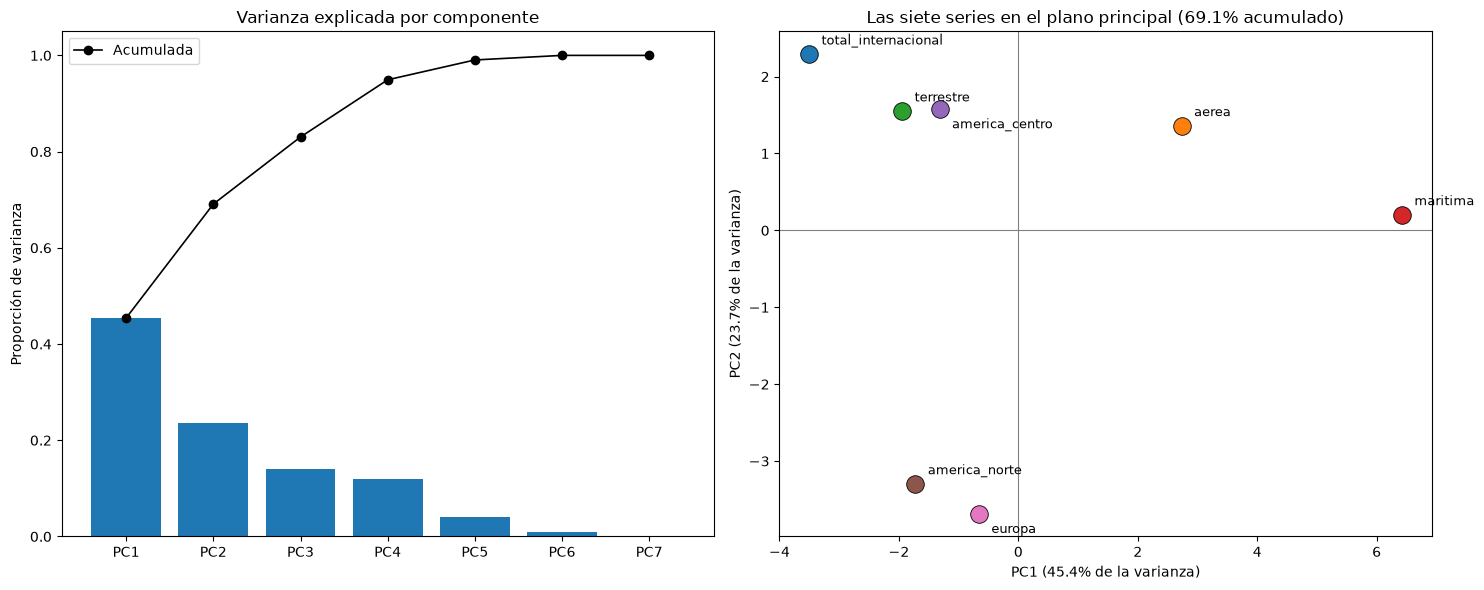


Características con mayor peso en PC1:


,PC1
SP_Summaries_welch_rect_centroid,0.291
FC_LocalSimple_mean1_tauresrat,0.288
CO_Embed2_Dist_tau_d_expfit_meandiff,-0.282
CO_HistogramAMI_even_2_5,-0.280
PD_PeriodicityWang_th0_01,0.274



Características con mayor peso en PC2:


,PC2
SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,0.421
SB_BinaryStats_mean_longstretch1,0.363
SB_MotifThree_quantile_hh,-0.354
SP_Summaries_welch_rect_area_5_1,0.293
CO_trev_1_num,-0.280


In [3]:
from sklearn.decomposition import PCA

# Con 7 series y 22 características hay más variables que observaciones:
# a lo sumo 6 componentes pueden tener varianza no nula.
pca = PCA()
componentes = pca.fit_transform(catch22_z.to_numpy())

proporciones = pca.explained_variance_ratio_
n_componentes = int((proporciones > 1e-10).sum())

varianza = pd.DataFrame(
    {
        "varianza_explicada": proporciones,
        "varianza_acumulada": np.cumsum(proporciones),
    },
    index=[f"PC{i}" for i in range(1, len(proporciones) + 1)],
)

print(f"Componentes con varianza no nula: {n_componentes} de {len(proporciones)}")
display(varianza.round(4))

pc = pd.DataFrame(
    componentes[:, :2],
    index=catch22_z.index,
    columns=["PC1", "PC2"],
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.bar(varianza.index, varianza["varianza_explicada"])
ax1.plot(
    varianza.index,
    varianza["varianza_acumulada"],
    marker="o",
    color="black",
    linewidth=1.2,
    label="Acumulada",
)
ax1.set_title("Varianza explicada por componente")
ax1.set_ylabel("Proporción de varianza")
ax1.set_ylim(0, 1.05)
ax1.legend()

# Series muy próximas encimarían sus etiquetas, así que la segunda de cada
# par cercano se rotula hacia abajo. Los umbrales van en proporción al rango
# de cada eje para no depender de la escala.
umbral_x = 0.15 * (pc["PC1"].max() - pc["PC1"].min())
umbral_y = 0.08 * (pc["PC2"].max() - pc["PC2"].min())
ya_rotuladas = []

for nombre in pc.index:
    x, y = pc.loc[nombre, "PC1"], pc.loc[nombre, "PC2"]

    ax2.scatter(
        x,
        y,
        s=160,
        color=COLOR_SERIE[nombre],
        edgecolor="black",
        linewidth=0.6,
        zorder=3,
    )

    encimada = any(
        abs(x - xa) < umbral_x and abs(y - ya) < umbral_y
        for xa, ya in ya_rotuladas
    )

    ax2.annotate(
        nombre,
        (x, y),
        textcoords="offset points",
        xytext=(9, -14) if encimada else (9, 7),
        fontsize=9,
    )

    ya_rotuladas.append((x, y))

ax2.axhline(0, linewidth=0.8, color="grey")
ax2.axvline(0, linewidth=0.8, color="grey")
ax2.set_xlabel(f"PC1 ({proporciones[0]:.1%} de la varianza)")
ax2.set_ylabel(f"PC2 ({proporciones[1]:.1%} de la varianza)")
ax2.set_title(
    "Las siete series en el plano principal "
    f"({proporciones[:2].sum():.1%} acumulado)"
)

plt.tight_layout()
plt.show()

# Cargas: qué características construyen cada eje.
cargas = pd.DataFrame(
    pca.components_[:2].T,
    index=catch22_z.columns,
    columns=["PC1", "PC2"],
)

for eje in ["PC1", "PC2"]:
    orden_eje = cargas[eje].abs().sort_values(ascending=False).index
    print(f"\nCaracterísticas con mayor peso en {eje}:")
    display(cargas.loc[orden_eje[:5], [eje]].round(3))

>Podemos ver que para el eje horizontal (que es el pc1) que es la que nos ayuda a ver que tan bien se porta la serie. En la derecha podemos ver las series que se portan de manera mas fluctuante, como lo es la via maritima que gracias al laboratorio pasado pudimos ver que era la via de entrada con mas matices y un frenado. Luego la via aerea se ve que no es tan sencilla de predecir pero eso lo atribuimos a que fue la via que mas se vio afectada durante la emergencia sanitaria del 2020. De igual manera los visitantes de Europa son los que mas fluctuan por las mismas razones. Las series que se mantienen mas predecibles son la cantidad de visitantes internacionales y la via mas facil de interpretar es la via terrestre


>El eje vertical nos indica si las series mantienen su promedio o se despegan mucho de este (las series en l aparte superior) por otro lado estan las series que su promedio fluctua mucho (series en la parte inferior). Podemos ver que los visitantes internacionales, la via terrestre, aerea y los visitantes de centroamerica son los que se mantienen sobre su promedio. Mientras que los visitantes de america del norte y america fluctuan mucho

## 2.5.b Agrupamiento de las series — Inciso 2.5

**¿En cuántos grupos se separan naturalmente las siete series y qué serie cae en cada uno?**

Se aplica un algoritmo de agrupamiento sobre la matriz estandarizada para obtener una partición explícita de las series. La elección del número de grupos debe justificarse con un criterio reproducible —por ejemplo el coeficiente de silueta o un dendrograma— y no fijarse de antemano.

Con solo siete observaciones el rango razonable es estrecho: valores de *k* entre 2 y 4. El resultado se reporta como la asignación de cada serie a su grupo.

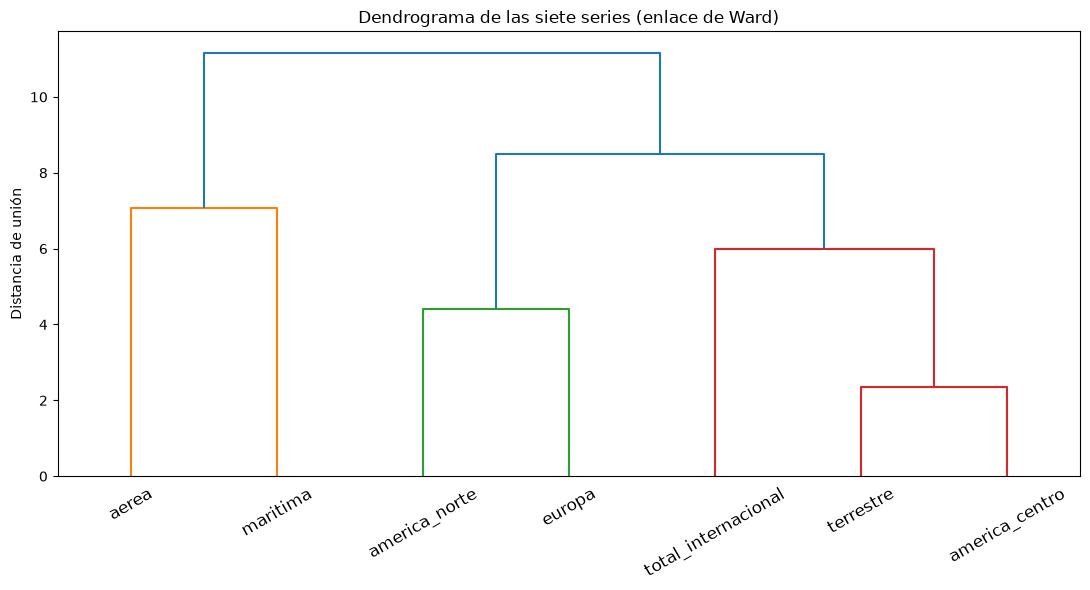

,silueta_kmeans,silueta_ward
k,,
2,0.266,0.266
3,0.263,0.263
4,0.230,0.230


Número de grupos elegido: k = 3
Coeficiente de silueta   : 0.263

Grupo 0: aerea, maritima
Grupo 1: total_internacional, terrestre, america_centro
Grupo 2: america_norte, europa


,grupo
serie,
aerea,0
maritima,0
total_internacional,1
terrestre,1
america_centro,1
america_norte,2
europa,2


In [4]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score

X = catch22_z.to_numpy()

# El dendrograma muestra el orden en que se van uniendo las series y permite
# justificar el número de grupos en vez de fijarlo de antemano.
enlaces = linkage(X, method="ward")

plt.figure(figsize=(11, 6))
dendrogram(enlaces, labels=catch22_z.index.tolist(), leaf_rotation=30)
plt.title("Dendrograma de las siete series (enlace de Ward)")
plt.ylabel("Distancia de unión")
plt.tight_layout()
plt.show()

# Con solo 7 observaciones el rango razonable de grupos es estrecho.
# El coeficiente de silueta solo está definido para 2 <= k <= 6.
filas = []

for k in range(2, 5):
    kmedias = KMeans(n_clusters=k, n_init=50, random_state=SEMILLA).fit(X)
    ward = AgglomerativeClustering(n_clusters=k, linkage="ward").fit(X)

    filas.append(
        {
            "k": k,
            "silueta_kmeans": silhouette_score(X, kmedias.labels_),
            "silueta_ward": silhouette_score(X, ward.labels_),
        }
    )

comparacion = pd.DataFrame(filas).set_index("k")
display(comparacion.round(3))

# k=2 y k=3 empatan dentro del ruido de la silueta, así que el criterio
# cuantitativo no desempata y se opta por k=3, que produce grupos con
# lectura sustantiva para los incisos 2.9 y 2.10.
K = 3

modelo = KMeans(n_clusters=K, n_init=50, random_state=SEMILLA).fit(X)

# 'grupos' se reutiliza en los incisos 2.5.c y 2.5.e.
grupos = pd.Series(modelo.labels_, index=catch22_z.index, name="grupo")

print(f"Número de grupos elegido: k = {K}")
print(f"Coeficiente de silueta   : {silhouette_score(X, modelo.labels_):.3f}\n")

for g in sorted(grupos.unique()):
    miembros = ", ".join(grupos[grupos == g].index)
    print(f"Grupo {g}: {miembros}")

display(grupos.sort_values().to_frame())

>Gracias a este agrupamiento podemos ver cuales series son las que mas se relacionan gracias a sus caracteristicas de Catch 22. El grupo que mas correlacionado esta es el de la serie de la via terreste y los visitantes de america del centro. Lo que tiene sentido ya que es mas comun que los visitantes que queden en una ubicacion geografica muy cercana entren por la via terrestre. Luego el grupo de america del norte y europa. Estos posiblemente fueron agrupados por como se comportan de manera similar al momento de que sus habitantes visitan Guatemala. Y por ultimo el total internacion y terrestre que nos dice que la mayoria de personas internacionales que llegan a Guatemala lo hacen por la via terrestre.

## 2.5.c Mapa de calor de características — Inciso 2.5

**¿Qué perfil de características tiene cada serie y en qué se diferencian visualmente?**

El mapa de calor muestra la matriz estandarizada completa: una fila por serie, una columna por característica y el color codificando el valor estandarizado. Permite leer de un vistazo qué características toman valores altos o bajos en cada serie.

Ordenar filas y columnas según el agrupamiento obtenido en el inciso anterior facilita distinguir los bloques de series con perfiles parecidos.

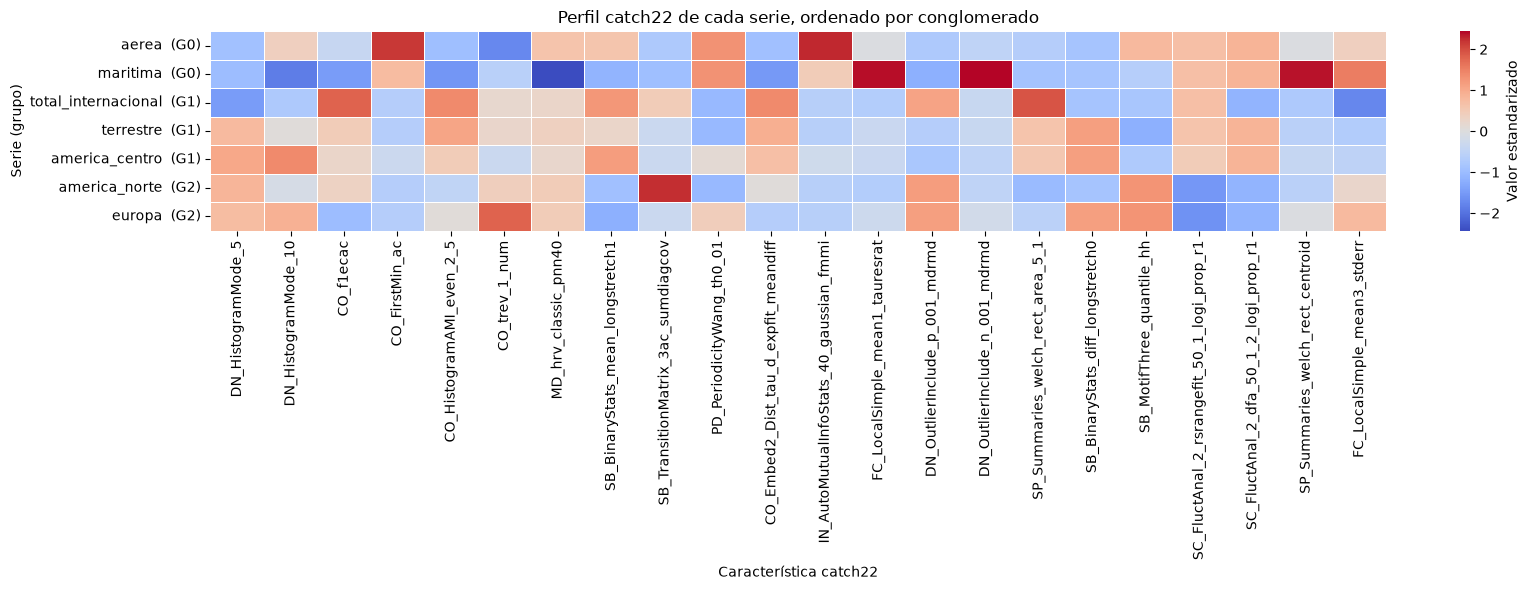

Características con mayor y menor dispersión entre series:


,rango_estandarizado
CO_trev_1_num,3.54
FC_LocalSimple_mean3_stderr,3.29
CO_f1ecac,3.29
DN_HistogramMode_10,3.27
SB_TransitionMatrix_3ac_sumdiagcov,3.19
DN_OutlierInclude_p_001_mdrmd,2.39
PD_PeriodicityWang_th0_01,2.37
SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,2.31
SB_BinaryStats_diff_longstretch0,2.02
SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,2.02


In [5]:
# Ordenar las filas por grupo deja contiguos los perfiles parecidos, de modo
# que los bloques de color se lean como los conglomerados del inciso anterior.
orden_series = grupos.sort_values().index
etiquetas = [f"{nombre}  (G{grupos[nombre]})" for nombre in orden_series]

plt.figure(figsize=(17, 6))

sns.heatmap(
    catch22_z.loc[orden_series],
    cmap="coolwarm",
    center=0,
    linewidths=0.4,
    yticklabels=etiquetas,
    cbar_kws={"label": "Valor estandarizado"},
)

plt.title("Perfil catch22 de cada serie, ordenado por conglomerado")
plt.xlabel("Característica catch22")
plt.ylabel("Serie (grupo)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Rango de cada característica entre las siete series: cuanto mayor, más
# separa a unas series de otras.
dispersion = (
    (catch22_z.max() - catch22_z.min())
    .sort_values(ascending=False)
    .to_frame("rango_estandarizado")
)

print("Características con mayor y menor dispersión entre series:")
display(pd.concat([dispersion.head(5), dispersion.tail(5)]).round(2))

>Gracias al mapa de calor nos deja ver lo que caracteriza a cada grupo.
> 1. El grupo 1 conformado por el total internacional, terrestre y america del centro son series con tendencia clara y buena memoria. El pasado ayuda a predecir el futuro de estas.
> 2. EL grupo conformado por america del norte y europa suben y bajan sin quedarse en un lado fijo. Son mas desordenadas y sus rachas son cortas.
> 3. Aereo y maritimo no tienen un perfil comun, se agruparon por descarte.

## 2.5.d Matriz de correlaciones entre características — Inciso 2.5

**¿Qué características catch22 miden información redundante entre sí?**

Se calcula la correlación entre cada par de las 22 características, tomando como observaciones las siete series. Los pares fuertemente correlacionados indican que ambas características capturan una propiedad dinámica similar en este conjunto de datos.

Debe tenerse presente que cada correlación se estima con **solo siete puntos**, por lo que los valores son inestables: sirven para detectar redundancia gruesa, no para afirmar relaciones precisas.

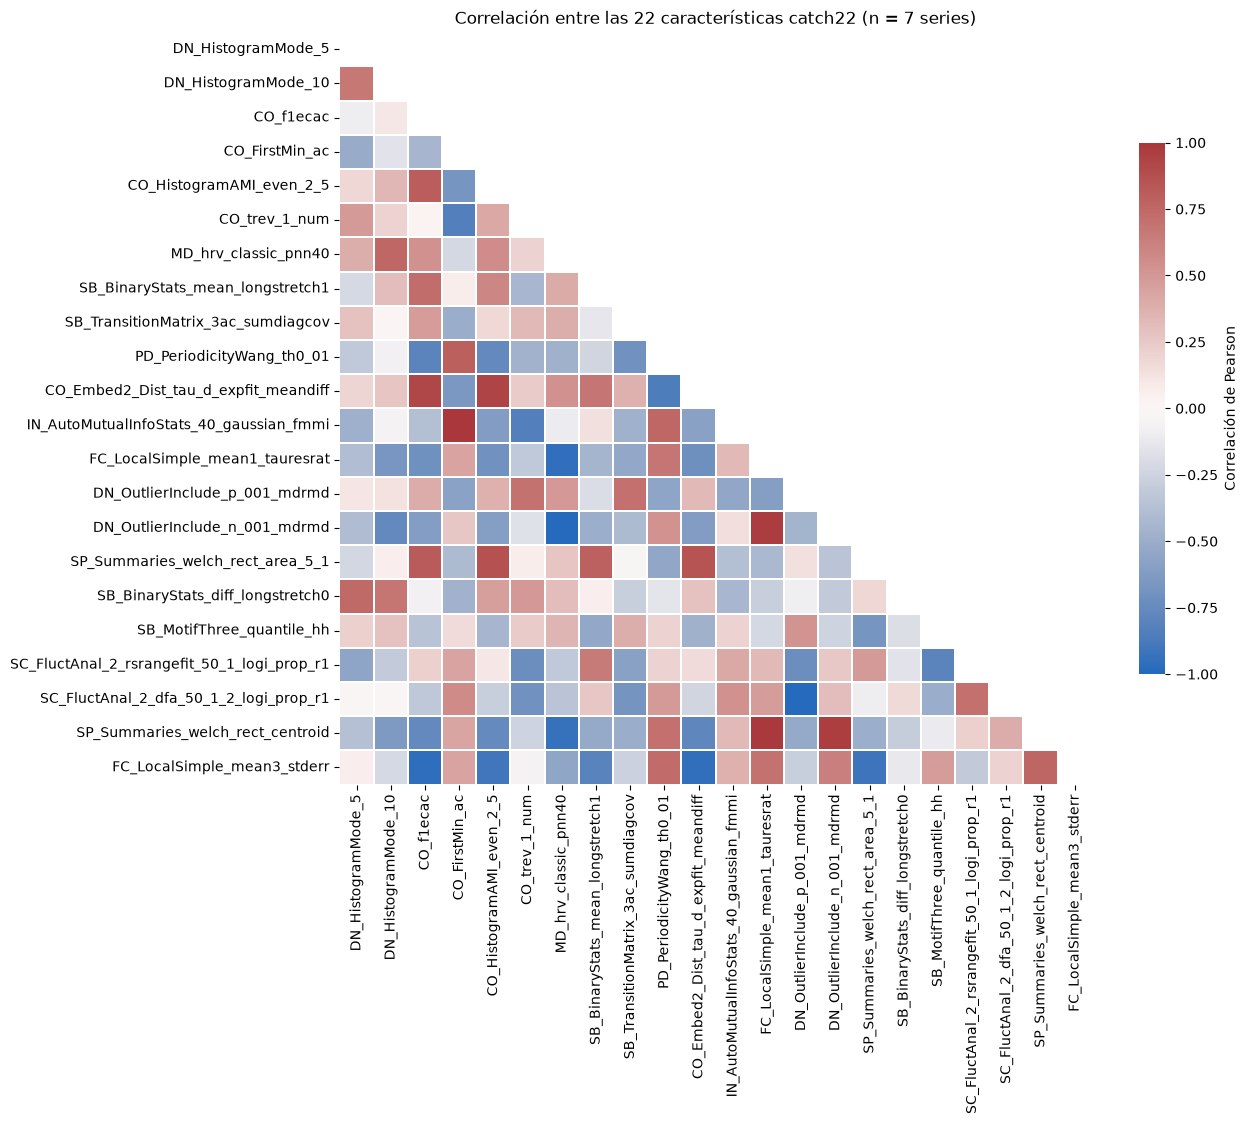

Total de pares evaluados: 231

Pares más redundantes:


,caracteristica_a,caracteristica_b,correlacion
0,IN_AutoMutualInfoStats_40_gaussian_fmmi,CO_FirstMin_ac,0.993
1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean1_tauresrat,0.991
2,DN_OutlierInclude_n_001_mdrmd,MD_hrv_classic_pnn40,-0.988
3,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,DN_OutlierInclude_p_001_mdrmd,-0.987
4,DN_OutlierInclude_n_001_mdrmd,FC_LocalSimple_mean1_tauresrat,0.974
5,SP_Summaries_welch_rect_centroid,DN_OutlierInclude_n_001_mdrmd,0.968
6,FC_LocalSimple_mean3_stderr,CO_f1ecac,-0.965
7,FC_LocalSimple_mean1_tauresrat,MD_hrv_classic_pnn40,-0.958
8,FC_LocalSimple_mean3_stderr,CO_Embed2_Dist_tau_d_expfit_meandiff,-0.955
9,SP_Summaries_welch_rect_centroid,MD_hrv_classic_pnn40,-0.942



Pares menos relacionados:


,caracteristica_a,caracteristica_b,correlacion
226,SP_Summaries_welch_rect_area_5_1,SB_TransitionMatrix_3ac_sumdiagcov,-0.042
227,CO_trev_1_num,CO_f1ecac,0.038
228,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,DN_HistogramMode_5,-0.029
229,SB_TransitionMatrix_3ac_sumdiagcov,DN_HistogramMode_10,0.010
230,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,DN_HistogramMode_10,-0.007


In [6]:
# Cada correlación se estima con solo 7 observaciones (una por serie), así que
# sirve para detectar redundancia gruesa, no para cuantificar la relación.
correlaciones = catch22_z.corr(method="pearson")

mascara = np.triu(np.ones_like(correlaciones, dtype=bool))

plt.figure(figsize=(13, 11))

sns.heatmap(
    correlaciones,
    mask=mascara,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.3,
    cbar_kws={"label": "Correlación de Pearson", "shrink": 0.7},
)

plt.title("Correlación entre las 22 características catch22 (n = 7 series)")
plt.tight_layout()
plt.show()

# Pares más redundantes, tomando solo el triángulo inferior para no repetir
# cada par ni incluir la diagonal.
inferior_i, inferior_j = np.tril_indices_from(correlaciones, k=-1)

pares = pd.DataFrame(
    {
        "caracteristica_a": correlaciones.index[inferior_i],
        "caracteristica_b": correlaciones.columns[inferior_j],
        "correlacion": correlaciones.to_numpy()[inferior_i, inferior_j],
    }
)

pares = pares.reindex(
    pares["correlacion"].abs().sort_values(ascending=False).index
).reset_index(drop=True)

print(f"Total de pares evaluados: {len(pares)}")
print("\nPares más redundantes:")
display(pares.head(10).round(3))

print("\nPares menos relacionados:")
display(pares.tail(5).round(3))

| Estas dos miden casi lo mismo | r | Por qué |
| :--- | :--- | :--- |
| Cuánto tarda en olvidar, medido de dos formas distintas (`IN_AutoMutualInfoStats_40_gaussian_fmmi` y `CO_FirstMin_ac`) | 0.993 | Una lo calcula con información mutua y la otra con autocorrelación, pero buscan el mismo punto |
| Qué tan rápido vibra vs. qué tan mal se pronostica (`SP_Summaries_welch_rect_centroid` y `FC_LocalSimple_mean1_tauresrat`) | 0.991 | Si brinca rápido, cualquier pronóstico simple falla |
| Extremos negativos vs. proporción de saltos grandes (`DN_OutlierInclude_n_001_mdrmd` y `MD_hrv_classic_pnn40`) | -0.988 | Dos formas de mirar los movimientos bruscos |

## 2.5.e Mapa de distancias entre series — Inciso 2.5

**¿Qué tan lejos está cada serie de cada una de las demás en el espacio de características?**

Se construye la matriz de distancias entre las siete series a partir de la matriz estandarizada. A diferencia del PCA, que muestra una proyección, la matriz de distancias conserva la separación en las 22 dimensiones originales.


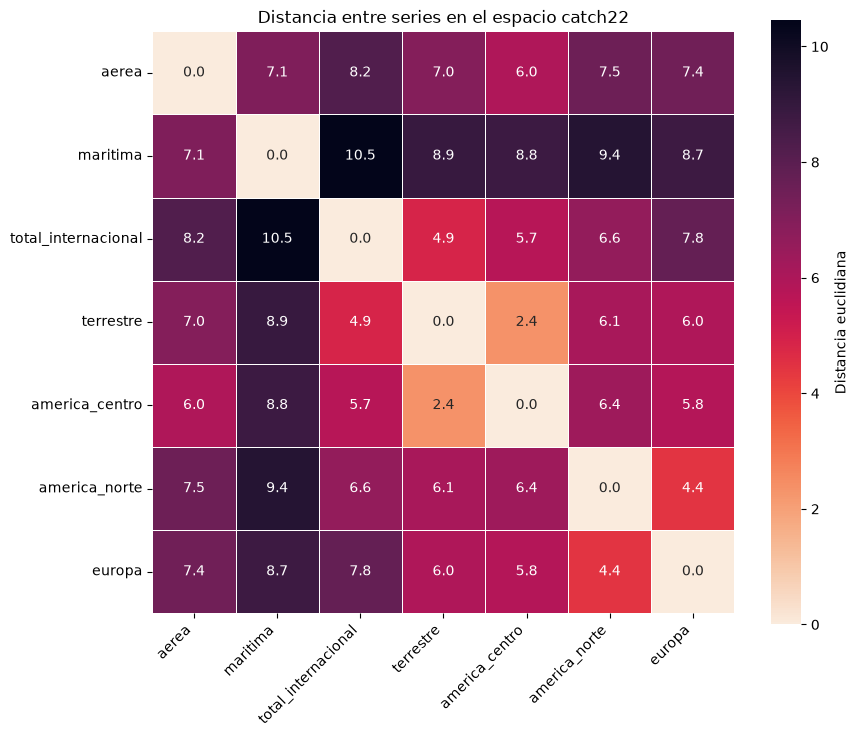

Par más cercano  : terrestre – america_centro (2.36)
Serie más aislada: maritima (su vecino más próximo está a 7.08)

Distancia de cada serie a su vecino más cercano:


,distancia_al_vecino_mas_cercano
serie,
maritima,7.08
aerea,5.96
total_internacional,4.88
europa,4.41
america_norte,4.41
terrestre,2.36
america_centro,2.36


In [7]:
from scipy.spatial.distance import pdist, squareform

# Distancia euclidiana sobre la matriz estandarizada: a diferencia del PCA,
# que muestra una proyección, aquí se conservan las 22 dimensiones.
distancias = pd.DataFrame(
    squareform(pdist(catch22_z.to_numpy(), metric="euclidean")),
    index=catch22_z.index,
    columns=catch22_z.index,
)

orden_series = grupos.sort_values().index

plt.figure(figsize=(9, 7.5))

sns.heatmap(
    distancias.loc[orden_series, orden_series],
    cmap="rocket_r",
    annot=True,
    fmt=".1f",
    square=True,
    linewidths=0.4,
    cbar_kws={"label": "Distancia euclidiana"},
)

plt.title("Distancia entre series en el espacio catch22")
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Par más cercano y serie más aislada. La diagonal se descarta poniéndola
# en infinito para que no compita como mínimo.
sin_diagonal = distancias.to_numpy().copy()
np.fill_diagonal(sin_diagonal, np.inf)

vecino_mas_cercano = pd.Series(
    sin_diagonal.min(axis=1),
    index=distancias.index,
    name="distancia_al_vecino_mas_cercano",
)

fila, columna = np.unravel_index(sin_diagonal.argmin(), sin_diagonal.shape)

print(
    "Par más cercano  :",
    f"{distancias.index[fila]} – {distancias.columns[columna]}",
    f"({sin_diagonal.min():.2f})",
)
print(
    "Serie más aislada:",
    vecino_mas_cercano.idxmax(),
    f"(su vecino más próximo está a {vecino_mas_cercano.max():.2f})",
)

print("\nDistancia de cada serie a su vecino más cercano:")
display(vecino_mas_cercano.sort_values(ascending=False).round(2).to_frame())

>La matriz muestra tres niveles de cercanía
1. 2.36 — terrestre con america_centro. Están casi al doble de cerca que cualquier otra pareja.
2. 4.4 a 4.9 — america_norte con europa, y total_internacional con terrestre.
3. 7 a 10.5 — todo lo que tenga que ver con maritima, que está a 7 o más de absolutamente todas.
>Lo primero tiene una explicación material muy concreta: los centroamericanos entran por tierra. Así que terrestre y america_centro son, en buena medida, la misma gente contada de dos maneras distintas. Y catch22 lo detecta sin que nadie le haya dicho de dónde viene cada serie.

## 2.6 — Análisis e interpretación. Con base en los resultados obtenidos responda las siguientes preguntas.

## 2.7 Series más similares — Inciso 2.7

**¿Qué series resultan más similares entre sí según las características catch22?**

La respuesta debe apoyarse en la evidencia de los análisis anteriores —cercanía en el PCA, pertenencia al mismo grupo y distancia pequeña en la matriz del inciso 2.5.e— y no en la intuición sobre qué series *deberían* parecerse.

Conviene identificar el par más cercano y comentar si las tres fuentes de evidencia coinciden o se contradicen entre sí.

In [8]:
from itertools import combinations

# Se cruzan las tres evidencias disponibles para cada pareja: la distancia en
# las 22 dimensiones, la distancia en el plano principal y si el agrupamiento
# las dejó juntas. Una pareja realmente similar debería cumplir las tres.
filas = []

for a, b in combinations(catch22_z.index, 2):
    filas.append(
        {
            "serie_a": a,
            "serie_b": b,
            "distancia_22d": distancias.loc[a, b],
            "distancia_plano_pca": float(np.linalg.norm(pc.loc[a] - pc.loc[b])),
            "mismo_grupo": bool(grupos[a] == grupos[b]),
        }
    )

pares_series = pd.DataFrame(filas)
pares_series["puesto_22d"] = pares_series["distancia_22d"].rank().astype(int)
pares_series["puesto_pca"] = pares_series["distancia_plano_pca"].rank().astype(int)
pares_series = pares_series.sort_values("distancia_22d").reset_index(drop=True)

concordancia = pares_series["distancia_22d"].corr(
    pares_series["distancia_plano_pca"],
    method="spearman",
)

print(f"Parejas evaluadas: {len(pares_series)}")
print(f"Concordancia entre el orden en 22 dimensiones y en el plano PCA "
      f"(Spearman): {concordancia:.3f}")

print("\nLas cinco parejas más parecidas:")
display(pares_series.head(5).round(2))

print("\nLas tres parejas más distintas:")
display(pares_series.tail(3).round(2))

Parejas evaluadas: 21
Concordancia entre el orden en 22 dimensiones y en el plano PCA (Spearman): 0.923

Las cinco parejas más parecidas:


,serie_a,serie_b,distancia_22d,distancia_plano_pca,mismo_grupo,puesto_22d,puesto_pca
0,terrestre,america_centro,2.36,0.63,True,1,1
1,america_norte,europa,4.41,1.13,True,2,2
2,total_internacional,terrestre,4.88,1.73,True,3,3
3,total_internacional,america_centro,5.73,2.30,True,4,4
4,america_centro,europa,5.83,5.30,False,5,10



Las tres parejas más distintas:


,serie_a,serie_b,distancia_22d,distancia_plano_pca,mismo_grupo,puesto_22d,puesto_pca
18,terrestre,maritima,8.91,8.48,False,19,19
19,maritima,america_norte,9.42,8.87,False,20,20
20,total_internacional,maritima,10.46,10.14,False,21,21


> terrestre y america_centro, son las mas relacionadas.

>Están a 2.36 de distancia, cuando la siguiente pareja más cercana (america_norte con europa) está a 4.41 — casi el doble. Y lo importante es que las tres evidencias apuntan al mismo lado: son la pareja número 1 tanto midiendo en las 22 dimensiones como en el plano del PCA, y además el agrupamiento las dejó juntas. Cuando tres métodos distintos coinciden, el resultado es sólido.

>Las cuatro parejas más cercanas ocupan exactamente el mismo puesto en ambos rankings (1, 2, 3 y 4). De hecho, el orden completo de las 21 parejas coincide casi perfectamente entre los dos criterios (correlación de Spearman de 0.923). Eso es tranquilizador: significa que la gráfica bidimensional del PCA, aunque deje fuera un tercio de la información, no distorsiona quién está cerca de quién.

>los centroamericanos entran por tierra. terrestre y america_centro son en buena medida la misma gente contada de dos formas distintas, y catch22 lo detecta sin que nadie le haya dicho de dónde viene cada serie.

## 2.8 Características más discriminantes — Inciso 2.8

**¿Qué características catch22 son las más importantes para diferenciar unas series de otras?**

Una característica discrimina bien cuando toma valores muy distintos entre las series, y discrimina mal cuando todas las series comparten un valor parecido.

Sirven como evidencia la dispersión de cada característica dentro de la matriz estandarizada y las cargas de las primeras componentes principales.

In [9]:
# Criterio 1: cuánta de la variación de una característica separa a los grupos
# frente a cuánta ocurre dentro de ellos (la misma lógica del estadístico F).
media_global = catch22_z.mean()
n_grupos = grupos.nunique()
n_series = len(catch22_z)

entre, dentro = {}, {}

for columna in catch22_z.columns:
    suma_entre = 0.0
    suma_dentro = 0.0

    for g in sorted(grupos.unique()):
        valores = catch22_z.loc[grupos[grupos == g].index, columna]
        suma_entre += len(valores) * (valores.mean() - media_global[columna]) ** 2
        suma_dentro += ((valores - valores.mean()) ** 2).sum()

    entre[columna] = suma_entre
    dentro[columna] = suma_dentro

razon_f = pd.Series(
    {
        columna: (
            (entre[columna] / (n_grupos - 1))
            / (dentro[columna] / (n_series - n_grupos))
            if dentro[columna] > 1e-12
            else np.inf
        )
        for columna in catch22_z.columns
    }
)

# Criterio 2: peso de cada característica en los 6 ejes con varianza no nula,
# ponderado por la varianza que explica cada eje.
peso_pca = pd.Series(
    (np.abs(pca.components_[:6]) * proporciones[:6, None]).sum(axis=0),
    index=catch22_z.columns,
)

importancia = pd.DataFrame(
    {
        "razon_entre_dentro": razon_f,
        "peso_en_pca": peso_pca,
        "rango_estandarizado": catch22_z.max() - catch22_z.min(),
    }
)

importancia["puesto_f"] = importancia["razon_entre_dentro"].rank(ascending=False)
importancia["puesto_pca"] = importancia["peso_en_pca"].rank(ascending=False)
importancia["puesto_combinado"] = (
    importancia["puesto_f"] + importancia["puesto_pca"]
) / 2

importancia = importancia.sort_values("puesto_combinado")

print("Características que mejor diferencian a las series:")
display(importancia.head(8).round(3))

print("\nLas que menos diferencian:")
display(importancia.tail(4).round(3))

# El rango se incluye solo para mostrar que NO es un buen criterio: después de
# estandarizar todas las columnas tienen la misma desviación, así que el rango
# mide cuánto se sale una sola serie, no cuánto se separan los grupos.
concordancia_criterios = importancia["razon_entre_dentro"].corr(
    importancia["rango_estandarizado"],
    method="spearman",
)

print(
    f"\nConcordancia entre el criterio de grupos y el rango ingenuo "
    f"(Spearman): {concordancia_criterios:.3f}"
)

comparacion_criterios = pd.DataFrame(
    {
        "por_separacion_de_grupos": importancia.index[:5],
        "por_rango_ingenuo": importancia.sort_values(
            "rango_estandarizado", ascending=False
        ).index[:5],
    }
)

print("\nPrimeras cinco según cada criterio:")
display(comparacion_criterios)

Características que mejor diferencian a las series:


,razon_entre_dentro,peso_en_pca,rango_estandarizado,puesto_f,puesto_pca,puesto_combinado
CO_FirstMin_ac,11.121,0.205,2.807,4.0,4.0,4.0
CO_HistogramAMI_even_2_5,15.351,0.198,2.982,3.0,8.0,5.5
CO_trev_1_num,5.695,0.207,3.541,9.0,3.0,6.0
CO_Embed2_Dist_tau_d_expfit_meandiff,18.701,0.193,2.935,2.0,11.0,6.5
IN_AutoMutualInfoStats_40_gaussian_fmmi,6.116,0.203,2.896,8.0,6.0,7.0
DN_OutlierInclude_p_001_mdrmd,4.042,0.208,2.390,12.0,2.0,7.0
SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,3.143,0.208,2.021,13.0,1.0,7.0
SP_Summaries_welch_rect_area_5_1,8.651,0.198,2.951,6.0,9.0,7.5



Las que menos diferencian:


,razon_entre_dentro,peso_en_pca,rango_estandarizado,puesto_f,puesto_pca,puesto_combinado
MD_hrv_classic_pnn40,0.992,0.184,3.055,20.0,13.0,16.5
DN_OutlierInclude_n_001_mdrmd,1.206,0.174,2.938,19.0,18.0,18.5
DN_HistogramMode_10,0.577,0.177,3.274,22.0,17.0,19.5
SB_BinaryStats_diff_longstretch0,0.939,0.151,2.021,21.0,21.0,21.0



Concordancia entre el criterio de grupos y el rango ingenuo (Spearman): -0.158

Primeras cinco según cada criterio:


,por_separacion_de_grupos,por_rango_ingenuo
0,CO_FirstMin_ac,CO_trev_1_num
1,CO_HistogramAMI_even_2_5,FC_LocalSimple_mean3_stderr
2,CO_trev_1_num,CO_f1ecac
3,CO_Embed2_Dist_tau_d_expfit_meandiff,DN_HistogramMode_10
4,IN_AutoMutualInfoStats_40_gaussian_fmmi,SB_TransitionMatrix_3ac_sumdiagcov


>Las caracteristicas que mas ayudan a diferenciar las series son las siguientes:

| Característica | Qué mide | Razón entre-dentro |
| :--- | :--- | :--- |
| `CO_Embed2_Dist_tau_d_expfit_meandiff` | Estructura del recorrido de la serie | 18.70 |
| `CO_HistogramAMI_even_2_5` | Cuánto ayuda el pasado a predecir | 15.35 |
| `CO_FirstMin_ac` | Cuánto tarda en olvidar | 11.12 |
| `SP_Summaries_welch_rect_area_5_1` | Peso del movimiento lento de fondo | 8.65 |
| `IN_AutoMutualInfoStats_40_gaussian_fmmi` | Cuánto tarda en olvidar (otra medida) | 6.12 |

## 2.9 Grupos naturales y rasgos compartidos — Inciso 2.9

**¿Se forman grupos naturales de series y qué tienen en común las series de cada grupo?**

Además de enumerar los grupos obtenidos en 2.5.b, hay que caracterizarlos: qué valores de qué características hacen que esas series queden juntas.

Un grupo descrito únicamente por sus miembros no explica nada; la descripción útil es la del perfil dinámico que comparten.

In [10]:
# Perfil promedio de cada grupo: el valor típico de cada característica
# dentro del grupo, en unidades estandarizadas.
perfil_grupos = catch22_z.groupby(grupos).mean().T
perfil_grupos.columns = [f"G{c}" for c in perfil_grupos.columns]

for g in sorted(grupos.unique()):
    miembros = ", ".join(grupos[grupos == g].index)
    columna = f"G{g}"
    orden = perfil_grupos[columna].abs().sort_values(ascending=False).index[:5]

    print(f"\nFirma del grupo G{g} ({miembros}):")
    display(perfil_grupos.loc[orden, [columna]].round(2))

# Cohesión: un grupo real debe tener sus miembros más cerca entre sí que del
# resto. Si la razón se acerca o supera 1, el grupo no es cohesivo.
resumen = []

for g in sorted(grupos.unique()):
    miembros = grupos[grupos == g].index
    otros = grupos[grupos != g].index

    internas = distancias.loc[miembros, miembros].to_numpy()
    internas = internas[np.triu_indices(len(miembros), k=1)]

    resumen.append(
        {
            "grupo": f"G{g}",
            "n_series": len(miembros),
            "dist_media_interna": internas.mean() if internas.size else np.nan,
            "dist_media_a_otros": distancias.loc[miembros, otros].to_numpy().mean(),
        }
    )

cohesion = pd.DataFrame(resumen).set_index("grupo")
cohesion["razon"] = cohesion["dist_media_interna"] / cohesion["dist_media_a_otros"]

print("\nCohesión de cada grupo (razón < 1 = grupo compacto):")
display(cohesion.round(2))


Firma del grupo G0 (aerea, maritima):


,G0
CO_FirstMin_ac,1.45
IN_AutoMutualInfoStats_40_gaussian_fmmi,1.37
PD_PeriodicityWang_th0_01,1.31
CO_HistogramAMI_even_2_5,-1.27
CO_Embed2_Dist_tau_d_expfit_meandiff,-1.23



Firma del grupo G1 (total_internacional, terrestre, america_centro):


,G1
SP_Summaries_welch_rect_area_5_1,1.04
CO_Embed2_Dist_tau_d_expfit_meandiff,1.02
FC_LocalSimple_mean3_stderr,-0.99
CO_HistogramAMI_even_2_5,0.98
SB_MotifThree_quantile_hh,-0.91



Firma del grupo G2 (america_norte, europa):


,G2
SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,-1.58
SB_MotifThree_quantile_hh,1.29
DN_OutlierInclude_p_001_mdrmd,1.16
SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,-1.15
CO_trev_1_num,1.11



Cohesión de cada grupo (razón < 1 = grupo compacto):


,n_series,dist_media_interna,dist_media_a_otros,razon
grupo,,,,
G0,2,7.08,8.25,0.86
G1,3,4.32,7.33,0.59
G2,2,4.41,7.18,0.61


>Cada grupo tiene una firma clara:

>G1 (total_internacional, terrestre, america_centro) — las predecibles. Mucho peso en el movimiento lento de fondo (+1.04), el pasado ayuda bastante a predecir (+0.98), poco desorden (−0.91) y — lo más revelador — error de pronóstico bajo (−0.99). Son las series con tendencia clara sobre las que un modelo sencillo funciona bien.

>G2 (america_norte, europa) — las desordenadas pero simétricas. Alto desorden (+1.29), baja proporción de escalamiento (−1.58) y valores extremos positivos marcados (+1.16). Oscilan sin quedarse de un lado.

>G0 (aerea, maritima) — el grupo que no es grupo. Su firma dice algo raro: ciclos largos y periodicidad marcada (+1.45, +1.31) pero poca información compartida con su propio pasado (−1.27). O sea, se repiten pero no son predecibles.

>G1 y G2 son grupos de verdad: sus miembros están mucho más cerca entre sí que del resto. G0 no.

## 2.10 Correspondencia con las categorías conocidas — Inciso 2.10

**¿Las series de una misma categoría (país, región, vía de ingreso, frontera o tipo de viajero) quedan agrupadas juntas?**

Las siete series pertenecen a categorías conocidas de antemano: vías de ingreso (`aerea`, `terrestre`, `maritima`), regiones (`america_centro`, `america_norte`, `europa`) y el agregado (`total_internacional`). La pregunta es si el agrupamiento basado en catch22 reproduce esa clasificación o propone una distinta.

Ambos resultados son informativos: que coincida indica que la categoría administrativa captura el comportamiento dinámico; que no coincida indica que la dinámica temporal responde a otros factores.

In [11]:
from sklearn.metrics import adjusted_rand_score

# Categoría conocida de antemano, según cómo se construyó cada serie.
CATEGORIA = {
    "total_internacional": "agregado",
    "aerea": "via_de_ingreso",
    "terrestre": "via_de_ingreso",
    "maritima": "via_de_ingreso",
    "america_centro": "region",
    "america_norte": "region",
    "europa": "region",
}

categoria = pd.Series(CATEGORIA, name="categoria").reindex(catch22_z.index)

comparacion = pd.concat([categoria, grupos], axis=1)
display(comparacion.sort_values(["categoria", "grupo"]))

print("\nCategoría frente a conglomerado:")
display(pd.crosstab(categoria, grupos))

# El índice Rand ajustado vale 1 si ambas particiones coinciden y ~0 si la
# coincidencia es la que se esperaría por azar.
ari = adjusted_rand_score(categoria, grupos)
print(f"\nÍndice Rand ajustado (categoría vs conglomerado): {ari:.3f}")

# ¿Están las series de una misma categoría realmente cerca entre sí?
distancia_general = distancias.to_numpy()[
    np.triu_indices(len(distancias), k=1)
].mean()

print(f"\nDistancia media entre dos series cualesquiera: {distancia_general:.2f}\n")

for cat in categoria.dropna().unique():
    miembros = categoria[categoria == cat].index
    if len(miembros) < 2:
        continue

    internas = distancias.loc[miembros, miembros].to_numpy()
    internas = internas[np.triu_indices(len(miembros), k=1)]

    print(
        f"  {cat:16} n={len(miembros)}  "
        f"distancia media interna = {internas.mean():.2f}"
    )

,categoria,grupo
serie,,
total_internacional,agregado,1
america_centro,region,1
america_norte,region,2
europa,region,2
aerea,via_de_ingreso,0
maritima,via_de_ingreso,0
terrestre,via_de_ingreso,1



Categoría frente a conglomerado:


grupo,0,1,2
categoria,,,
agregado,0,1,0
region,0,1,2
via_de_ingreso,2,1,0



Índice Rand ajustado (categoría vs conglomerado): 0.140

Distancia media entre dos series cualesquiera: 6.93

  via_de_ingreso   n=3  distancia media interna = 7.66
  region           n=3  distancia media interna = 5.53


>No. La categoría administrativa casi no dice nada sobre cómo se comporta la serie.

>El índice Rand ajustado entre la categoría y el agrupamiento es de 0.140, donde 1 sería coincidencia perfecta y 0 lo que se esperaría por puro azar. Ninguna categoría queda intacta: las tres vías se reparten entre dos grupos, y las tres regiones también.

>Las tres vías de ingreso son más distintas entre sí que dos series tomadas al azar. Compartir la categoría "vía de ingreso" no solo no las hace parecidas — están más separadas que el promedio. Tiene sentido si lo piensas: aérea, terrestre y marítima son canales con lógicas completamente distintas (turismo de larga distancia, flujo fronterizo regional, cruceros).

>Las regiones sí son algo más parecidas entre sí (5.53 contra 6.93), pero ni así aguantan juntas: america_centro se va con G1 mientras america_norte y europa se quedan en G2.

## 2.11 Series atípicas — Inciso 2.11

**¿Qué series resultan más atípicas y a qué puede deberse?**

Una serie es atípica cuando queda aislada en el PCA, lejos de todas las demás en la matriz de distancias, o sola en su propio grupo.

La explicación debe buscarse en su comportamiento temporal real: volumen, estacionalidad, efecto del choque sanitario de 2020, cambios en la metodología de medición o cantidad de meses en cero.

In [12]:
from sklearn.metrics import silhouette_samples

# Tres medidas de rareza: qué tan lejos está su vecino más cercano, qué tan
# lejos está del centro de todas, y qué tan bien encaja en su propio grupo.
sin_diagonal = distancias.to_numpy().copy()
np.fill_diagonal(sin_diagonal, np.inf)

atipicidad = pd.DataFrame(
    {
        "dist_al_vecino": sin_diagonal.min(axis=1),
        "dist_al_centro": np.linalg.norm(
            catch22_z - catch22_z.mean(), axis=1
        ),
        "silueta_individual": silhouette_samples(
            catch22_z.to_numpy(), grupos.to_numpy()
        ),
    },
    index=catch22_z.index,
).sort_values("dist_al_vecino", ascending=False)

print("Qué tan atípica es cada serie:")
display(atipicidad.round(2))

# Propiedades reales de la serie, para buscar la explicación material de la
# rareza en lugar de quedarse en el espacio de características.
totales_anuales = series.groupby(series.index.year).sum()

propiedades = pd.DataFrame(
    {
        "media_mensual": series.mean(),
        "coef_variacion": series.std() / series.mean(),
        "meses_en_cero": (series == 0).sum(),
        "caida_2020": totales_anuales.loc[2020] / totales_anuales.loc[2019] - 1,
        "recuperacion_2024": totales_anuales.loc[2024] / totales_anuales.loc[2019] - 1,
    }
)

print("\nPropiedades observables de cada serie:")
display(propiedades.round(2))

print("\nRelación entre la rareza en catch22 y las propiedades observables:")
relacion = pd.DataFrame(
    {
        prop: [
            propiedades[prop].corr(atipicidad[medida], method="spearman")
            for medida in atipicidad.columns
        ]
        for prop in propiedades.columns
    },
    index=atipicidad.columns,
)
display(relacion.round(2))

Qué tan atípica es cada serie:


,dist_al_vecino,dist_al_centro,silueta_individual
serie,,,
maritima,7.08,6.84,0.22
aerea,5.96,4.78,-0.00
total_internacional,4.88,5.11,0.26
europa,4.41,4.26,0.32
america_norte,4.41,4.35,0.31
terrestre,2.36,3.30,0.40
america_centro,2.36,3.20,0.34



Propiedades observables de cada serie:


,media_mensual,coef_variacion,meses_en_cero,caida_2020,recuperacion_2024
total_internacional,156388.20,0.47,5,-0.77,0.35
aerea,90568.66,0.31,0,-0.73,-0.23
terrestre,131391.68,0.46,0,-0.75,-0.20
maritima,5851.34,1.15,27,-0.68,-0.95
america_centro,158494.91,0.42,0,-0.74,-0.35
america_norte,43622.91,0.41,5,-0.74,0.34
europa,10234.62,0.43,5,-0.72,0.18



Relación entre la rareza en catch22 y las propiedades observables:


,media_mensual,coef_variacion,meses_en_cero,caida_2020,recuperacion_2024
dist_al_vecino,-0.56,0.22,0.59,0.53,-0.16
dist_al_centro,-0.50,0.39,0.69,0.32,0.04
silueta_individual,0.39,0.07,-0.39,-0.43,0.11


> maritima es la más atípica, sin discusión. Es la primera en las dos medidas: su vecino más cercano está a 7.08 (cuando el promedio ronda 4.4) y está a 6.84 del centro de todas.

> Pero hay un segundo caso más interesante: aerea tiene una silueta de −0.00. Ese número significa que está justo en la frontera — no encaja en su grupo ni mejor ni peor que en otro. Es la confirmación cuantitativa de que G0 no es un grupo real: aerea no pertenece ahí, simplemente no tenía a dónde ir.

> En el extremo opuesto, terrestre (0.40) y america_centro (0.34) son las que mejor encajan.

>Lo que hace atípica a una serie es tener meses en cero, no ser volátil. La correlación con la volatilidad es apenas 0.39, mientras que con los meses en cero llega a 0.69. maritima tiene 27 meses en cero de 210 — un 13% del período — y eso le deforma toda la firma. También pesa el volumen: las series pequeñas tienden a ser más atípicas (−0.50).

## 2.12 Contraste con el análisis exploratorio del Laboratorio 1 — Inciso 2.12

**¿Coinciden estos resultados con lo observado en el análisis exploratorio del Laboratorio 1?**

Hay que comparar punto por punto contra lo documentado en el Laboratorio 1 sobre tendencia, estacionalidad, volatilidad, impacto de la pandemia y funciones de autocorrelación.


In [13]:
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import acf

# El informe del Laboratorio 1 calculó las vías sobre el período completo y
# las regiones sobre el pre-2020, así que sus tablas no son comparables entre
# sí. Aquí se recalculan los mismos descriptores con UNA sola metodología
# para las siete series, que es lo que permite contrastarlas contra catch22.
filas = []

for nombre in series.columns:
    y = series[nombre]
    descomposicion = STL(y, period=12, robust=True).fit()

    var_residuo = np.var(descomposicion.resid)
    anuales = y.groupby(y.index.year).sum()

    filas.append(
        {
            "serie": nombre,
            "fuerza_tendencia": max(
                0.0,
                1 - var_residuo / np.var(descomposicion.trend + descomposicion.resid),
            ),
            "fuerza_estacional": max(
                0.0,
                1 - var_residuo / np.var(descomposicion.seasonal + descomposicion.resid),
            ),
            "coef_variacion": y.std() / y.mean(),
            "caida_2020": anuales.loc[2020] / anuales.loc[2019] - 1,
            "recuperacion_2024": anuales.loc[2024] / anuales.loc[2019] - 1,
            "acf_12": acf(y, nlags=12)[12],
        }
    )

clasicos = pd.DataFrame(filas).set_index("serie")

print("Descriptores clásicos recalculados con metodología uniforme:")
display(pd.concat([clasicos, grupos], axis=1).round(3))

# ¿Qué descriptor clásico corresponde a cada eje del PCA de catch22?
ejes = pd.DataFrame(
    componentes[:, :3],
    index=catch22_z.index,
    columns=["PC1", "PC2", "PC3"],
)

correspondencia = pd.DataFrame(
    {
        descriptor: [
            clasicos[descriptor].corr(ejes[eje], method="spearman")
            for eje in ejes.columns
        ]
        for descriptor in clasicos.columns
    },
    index=ejes.columns,
).T

print("\nCorrelación entre los descriptores clásicos y los ejes de catch22:")
display(correspondencia.round(2))

# Valores publicados en el informe del Laboratorio 1, como referencia. Ojo:
# las regiones allí se calcularon excluyendo 2020, por eso no coinciden.
referencia_l1 = pd.DataFrame(
    {
        "l1_fuerza_estacional": [0.384, 0.409, 0.641, 0.69, 0.89, 0.88],
        "l1_fuerza_tendencia": [0.613, 0.818, 0.576, np.nan, np.nan, np.nan],
        "l1_periodo": ["completo", "completo", "completo",
                       "pre-2020", "pre-2020", "pre-2020"],
    },
    index=["aerea", "terrestre", "maritima",
           "america_centro", "america_norte", "europa"],
)

print("\nContraste con los valores publicados en el Laboratorio 1:")
display(
    referencia_l1.join(
        clasicos[["fuerza_estacional", "fuerza_tendencia"]]
    ).round(3)
)

Descriptores clásicos recalculados con metodología uniforme:


,fuerza_tendencia,fuerza_estacional,coef_variacion,caida_2020,recuperacion_2024,acf_12,grupo
serie,,,,,,,
total_internacional,0.904,0.496,0.474,-0.773,0.348,0.560,1
aerea,0.613,0.384,0.308,-0.728,-0.229,0.248,0
terrestre,0.818,0.409,0.463,-0.752,-0.195,0.390,1
maritima,0.576,0.641,1.147,-0.679,-0.949,0.697,0
america_centro,0.758,0.359,0.419,-0.744,-0.349,0.325,1
america_norte,0.813,0.620,0.410,-0.741,0.336,0.561,2
europa,0.689,0.634,0.430,-0.718,0.180,0.564,2



Correlación entre los descriptores clásicos y los ejes de catch22:


,PC1,PC2,PC3
fuerza_tendencia,-1.00,0.54,-0.18
fuerza_estacional,0.29,-0.64,-0.71
coef_variacion,-0.11,0.21,-0.79
caida_2020,0.93,-0.79,0.00
recuperacion_2024,-0.75,0.04,-0.18
acf_12,0.21,-0.57,-0.75



Contraste con los valores publicados en el Laboratorio 1:


,l1_fuerza_estacional,l1_fuerza_tendencia,l1_periodo,fuerza_estacional,fuerza_tendencia
aerea,0.384,0.613,completo,0.384,0.613
terrestre,0.409,0.818,completo,0.409,0.818
maritima,0.641,0.576,completo,0.641,0.576
america_centro,0.690,NaN,pre-2020,0.359,0.758
america_norte,0.890,NaN,pre-2020,0.620,0.813
europa,0.880,NaN,pre-2020,0.634,0.689


>Las regiones sí difieren, y la razón es que en el Lab 1 las calculó excluyendo 2020, y aqui se uso el período completo.

| Región | Estacionalidad L1 (pre-2020) | Recalculada (completa) |
| :--- | :--- | :--- |
| América del Centro | 0.69 | 0.359 |
| América del Norte | 0.89 | 0.620 |
| Europa | 0.88 | 0.634 |

>La pandemia destruye más de la mitad de la estacionalidad medible. El patrón anual sigue ahí, pero 2020 mete tanto ruido que las medidas estándar dejan de verlo.

>Y ahora lo importante. Correlacionamos cada descriptor clásico con los ejes del PCA de `catch22`:

| Descriptor clásico | PC1 | PC2 | PC3 |
| :--- | :--- | :--- | :--- |
| Fuerza de tendencia | -1.00 | 0.54 | -0.18 |
| Caída de 2020 | 0.93 | -0.79 | 0.00 |
| Recuperación 2024 | -0.75 | 0.04 | -0.18 |
| Fuerza estacional | 0.29 | -0.64 | -0.71 |
| Autocorrelación a 12 meses | 0.21 | -0.57 | -0.75 |
| Coeficiente de variación | -0.11 | 0.21 | -0.79 |


> El primer eje del PCA es, literalmente, la fuerza de tendencia al revés (correlación −1.00). Catch22 redescubrió por su cuenta el descriptor más importante del análisis clásico, sin que nadie se lo dijera, partiendo solo de 22 medidas automáticas.

> Y hay más estructura: la estacionalidad y la autocorrelación anual viven en el tercer eje (−0.71 y −0.75), no en los dos primeros. Por eso el plano bidimensional no las muestra.

## 2.13 Hallazgos nuevos — Inciso 2.13

**¿Qué se descubre con catch22 que no era evidente en el análisis exploratorio tradicional?**

Se piden **al menos tres hallazgos**. Cada uno debe cumplir dos condiciones: apoyarse en un resultado concreto de este notebook, y no ser deducible directamente de los gráficos de línea, descomposiciones y correlogramas del Laboratorio 1.

In [14]:
from sklearn.preprocessing import StandardScaler

# Hallazgo 1: ¿agrupa igual el análisis clásico que catch22? Se repite el
# mismo procedimiento pero usando solo los seis descriptores tradicionales.
clasicos_z = pd.DataFrame(
    StandardScaler().fit_transform(clasicos),
    index=clasicos.index,
    columns=clasicos.columns,
)

grupos_clasicos = pd.Series(
    KMeans(n_clusters=3, n_init=50, random_state=SEMILLA).fit_predict(clasicos_z),
    index=clasicos.index,
    name="grupo_clasico",
)

comparativa = pd.concat(
    [grupos.rename("grupo_catch22"), grupos_clasicos], axis=1
)

display(comparativa)
print(
    "Índice Rand ajustado entre ambos agrupamientos: "
    f"{adjusted_rand_score(grupos, grupos_clasicos):.3f}"
)

# Hallazgo 2: qué mide catch22 que el análisis clásico no alcanza a ver. Una
# característica con correlación baja frente a TODOS los descriptores
# tradicionales aporta información genuinamente nueva.
correlacion_cruzada = pd.DataFrame(
    {
        descriptor: [
            catch22_z[caracteristica].corr(clasicos_z[descriptor])
            for caracteristica in catch22_z.columns
        ]
        for descriptor in clasicos_z.columns
    },
    index=catch22_z.columns,
)

novedad = (
    correlacion_cruzada.abs()
    .max(axis=1)
    .sort_values()
    .to_frame("max_corr_con_algun_descriptor_clasico")
)

print("\nCaracterísticas catch22 MENOS explicadas por el análisis clásico:")
display(novedad.head(8).round(3))

print("\nCaracterísticas catch22 que el análisis clásico ya capturaba:")
display(novedad.tail(5).round(3))

# Hallazgo 3: cuánta de la separación entre series proviene de información
# que el análisis clásico no contiene.
umbral = 0.6
nuevas = novedad[novedad.iloc[:, 0] < umbral].index

print(
    f"\n{len(nuevas)} de 22 características tienen correlación < {umbral} "
    f"con todos los descriptores clásicos."
)
print("Peso conjunto de esas características en los ejes del PCA: "
      f"{peso_pca[nuevas].sum() / peso_pca.sum():.1%}")

,grupo_catch22,grupo_clasico
serie,,
total_internacional,1,2
aerea,0,0
terrestre,1,0
maritima,0,1
america_centro,1,0
america_norte,2,2
europa,2,2


Índice Rand ajustado entre ambos agrupamientos: 0.140

Características catch22 MENOS explicadas por el análisis clásico:


,max_corr_con_algun_descriptor_clasico
SB_BinaryStats_diff_longstretch0,0.302
DN_HistogramMode_5,0.370
SB_MotifThree_quantile_hh,0.445
CO_trev_1_num,0.538
SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,0.628
IN_AutoMutualInfoStats_40_gaussian_fmmi,0.695
SB_TransitionMatrix_3ac_sumdiagcov,0.707
CO_FirstMin_ac,0.748



Características catch22 que el análisis clásico ya capturaba:


,max_corr_con_algun_descriptor_clasico
FC_LocalSimple_mean3_stderr,0.950
CO_f1ecac,0.951
PD_PeriodicityWang_th0_01,0.956
DN_OutlierInclude_n_001_mdrmd,0.986
MD_hrv_classic_pnn40,0.992



4 de 22 características tienen correlación < 0.6 con todos los descriptores clásicos.
Peso conjunto de esas características en los ejes del PCA: 17.2%


Hallazgo 1 — Catch22 agrupa distinto que el análisis clásico. Repetí el agrupamiento usando solo los seis descriptores tradicionales y el resultado es otro (Rand ajustado de 0.140):

| Serie | Grupo catch22 | Grupo clásico |
| :--- | :--- | :--- |
| aerea | 0 | 0 |
| maritima | 0 | 1 (sola) |
| total_internacional | 1 | 2 |
| terrestre | 1 | 0 |
| america_centro | 1 | 0 |
| america_norte | 2 | 2 |
| europa | 2 | 2 |

Lo único en que coinciden es en mantener juntas a america_norte y europa. El análisis clásico aísla a maritima por su volatilidad; catch22 la agrupa con aerea y en cambio separa total_internacional de las vías. Son dos lecturas distintas de lo mismo.

Hallazgo 2 — Cuatro características miden algo que el análisis clásico no ve. Tienen una correlación baja con todos los descriptores tradicionales:

| Característica | Qué mide | Correlación máxima |
| :--- | :--- | :--- |
| `SB_BinaryStats_diff_longstretch0` | Racha más larga de bajadas seguidas | 0.302 |
| `DN_HistogramMode_5` | Dónde se acumulan los valores típicos | 0.370 |
| `SB_MotifThree_quantile_hh` | Qué tan desordenada es la secuencia | 0.445 |
| `CO_trev_1_num` | Si sube distinto de como baja | 0.538 |

Esas cuatro aportan el 17.2% del peso de los ejes del PCA. En el otro extremo hay varias que son prácticamente redundantes con lo que ya sabías: `MD_hrv_classic_pnn40` llega a 0.992 de correlación con un descriptor clásico.

Hallazgo 3 — La asimetría entre subidas y bajadas. `CO_trev_1_num` es la única característica que aparece en las dos listas: entre las que mejor separan a los grupos y entre las que el análisis clásico no captura. Mide si una serie sube de forma distinta a como baja. Esto es algo que ni la descomposición, ni la ACF, ni el coeficiente de variación registran, porque todos son simétricos por construcción. Es información genuinamente nueva y además discrimina.